In [2]:
import cv2
import os

In [5]:


# Path to your video file
video_path = "checkerboard_video_20250915_160221.mp4"

# Folder where frames will be saved
output_folder = "cft"

# Create folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Open the video file
cap = cv2.VideoCapture(video_path)

# Get total number of frames (optional)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Total frames: {total_frames}")

frame_id = 1133

while True:
    success, frame = cap.read()
    if not success:
        break  # Stop when video ends
    
    # Build filename
    filename = os.path.join(output_folder, f"frame_{frame_id:04d}.jpg")
    
    # Save the frame as JPG
    cv2.imwrite(filename, frame)
    
    frame_id += 1

cap.release()
print(f"Extracted {frame_id} frames to '{output_folder}'")


Total frames: 371
Extracted 1504 frames to 'cft'


✅ Saved 'asymmetric_circle_grid_A3_25mm_39mm_10cols_shifted.png'


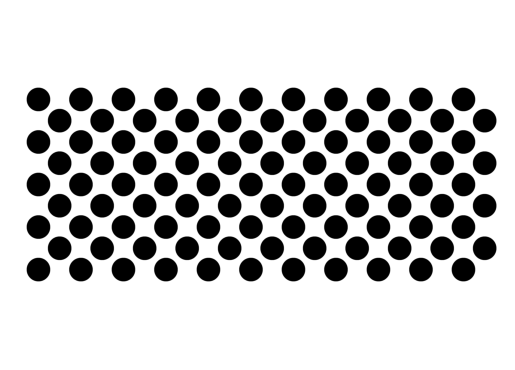

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# --- CONFIGURATION ---
rows = 9             # number of circle rows
cols = 10            # number of circle columns
circle_diameter_mm = 25  # diameter of each circle in millimeters
spacing_mm = 40          # center-to-center spacing (horizontal distance)
paper_size_mm = (420, 297)  # A3 paper size (width x height in mm)
dpi = 300  # print resolution

# --- CALCULATIONS ---
mm_to_inch = 1 / 25.4
img_size_px = (
    int(paper_size_mm[0] * dpi * mm_to_inch),
    int(paper_size_mm[1] * dpi * mm_to_inch)
)

circle_diameter_px = int(circle_diameter_mm * dpi * mm_to_inch)
spacing_px = int(spacing_mm * dpi * mm_to_inch)

# Create white A3 canvas
img = np.ones((img_size_px[1], img_size_px[0]), dtype=np.uint8) * 255

# Compute grid size
grid_w = (cols - 1) * spacing_px
grid_h = (rows - 1) * spacing_px / 2.0


vertical_margin = img.shape[0] - grid_h
start_y = int(vertical_margin / 2 ) 
Hm = ((img.shape[1] - grid_w) / 2)
start_x = int(Hm - Hm*0.20)

for i in range(rows):
    for j in range(cols):
        cx = int(start_x + j * spacing_px + (spacing_px / 2 if i % 2 else 0))
        cy = int(start_y + i * (spacing_px / 2))
        cv2.circle(img, (cx, cy), circle_diameter_px // 2, (0,), -1)



cv2.imwrite("asymmetric_circle_grid_A3_20mm_36mm_11cols_9rows.png", img)


plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


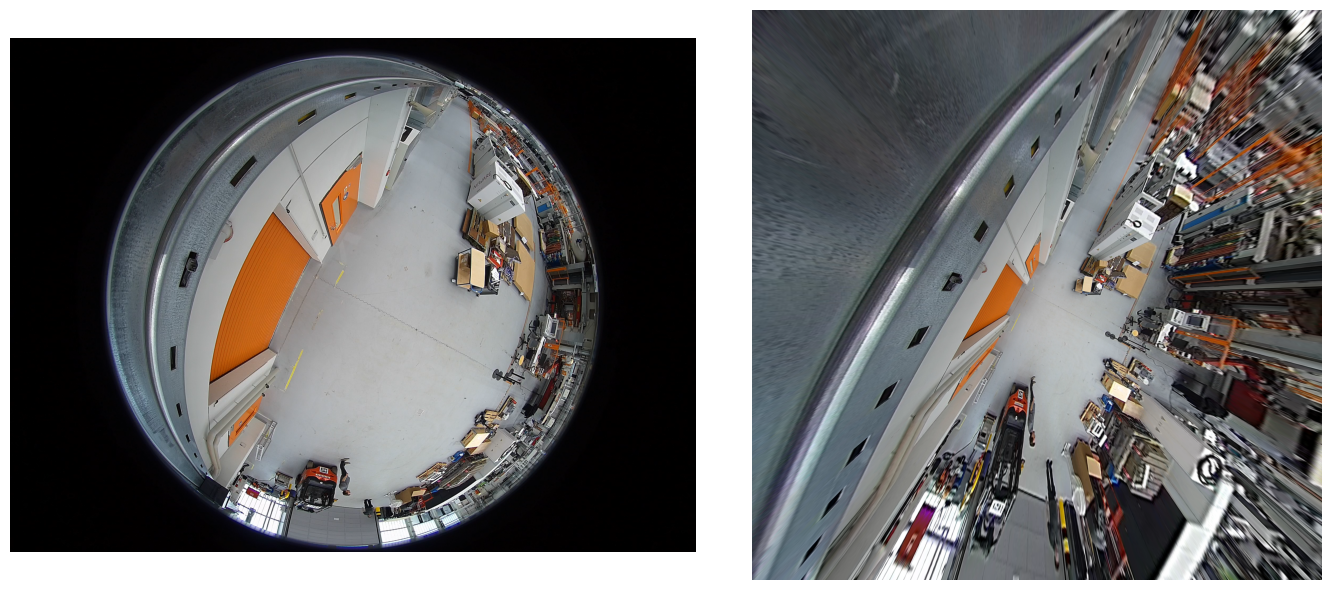

In [99]:

fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708  
}


fisheye_img = cv2.imread("20251104_115055.png")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]


rect_w, rect_h = 2560,2560
rect_w_c, rect_h_c = rect_w/2, rect_h/2
fov = 160.0                    
fov_RAD = np.deg2rad(fov)
focal = (rect_w_c) / np.tan(fov_RAD / 2)

x_rect, y_rect = np.meshgrid(np.arange(rect_w), np.arange(rect_h))
x_norm = (x_rect - rect_w_c) / focal
y_norm = (y_rect - rect_h_c) / focal
z = np.ones_like(x_norm)

dirs = np.stack([x_norm, y_norm, z], axis=-1)
r = np.linalg.norm(dirs, axis=-1)
dirs /= np.maximum(r, 1e-8)[..., None]
r=np.linalg.norm(dirs,axis=1)

theta = np.arccos(dirs[..., 2])            
phi = np.arctan2(dirs[..., 1], dirs[..., 0]) 
theta = np.minimum(theta, theta_max)

r_fish = radius * (theta / theta_max)
u_fish = cx_f + r_fish * np.cos(phi)
v_fish = cy_f + r_fish * np.sin(phi)

map_x = u_fish.astype(np.float32)
map_y = v_fish.astype(np.float32)
rectilinear = cv2.remap(fisheye_img, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

orig_rgb = cv2.cvtColor(fisheye_img, cv2.COLOR_BGR2RGB)
rect_rgb = cv2.cvtColor(rectilinear, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(orig_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rect_rgb)
plt.axis("off")
plt.tight_layout()
plt.show()



(12, 1, 2)
Fisheye point (1296.0, 972.0) Rectified point (1280.0, 1280.0)
Fisheye point (1600.0, 900.0) Rectified point (1404.0, 1250.0)
Fisheye point (1000.0, 1200.0) Rectified point (1153.0, 1377.0)
Fisheye point (1296.0, 500.0) Rectified point (1280.0, 1057.0)
Fisheye point (1295.0, 1600.0) Rectified point (1279.0, 1660.0)
Fisheye point (1200.0, 1610.0) Rectified point (1219.0, 1681.0)
Fisheye point (1350.0, 1740.0) Rectified point (1330.0, 2004.0)
Fisheye point (1700.0, 250.0) Rectified point (1806.0, 339.0)
Fisheye point (1200.0, 200.0) Rectified point (1185.0, 523.0)
Fisheye point (1700.0, 400.0) Rectified point (1574.0, 862.0)
Fisheye point (1850.0, 1250.0) Rectified point (1610.0, 1445.0)
Fisheye point (2010.0, 900.0) Rectified point (1830.0, 1224.0)


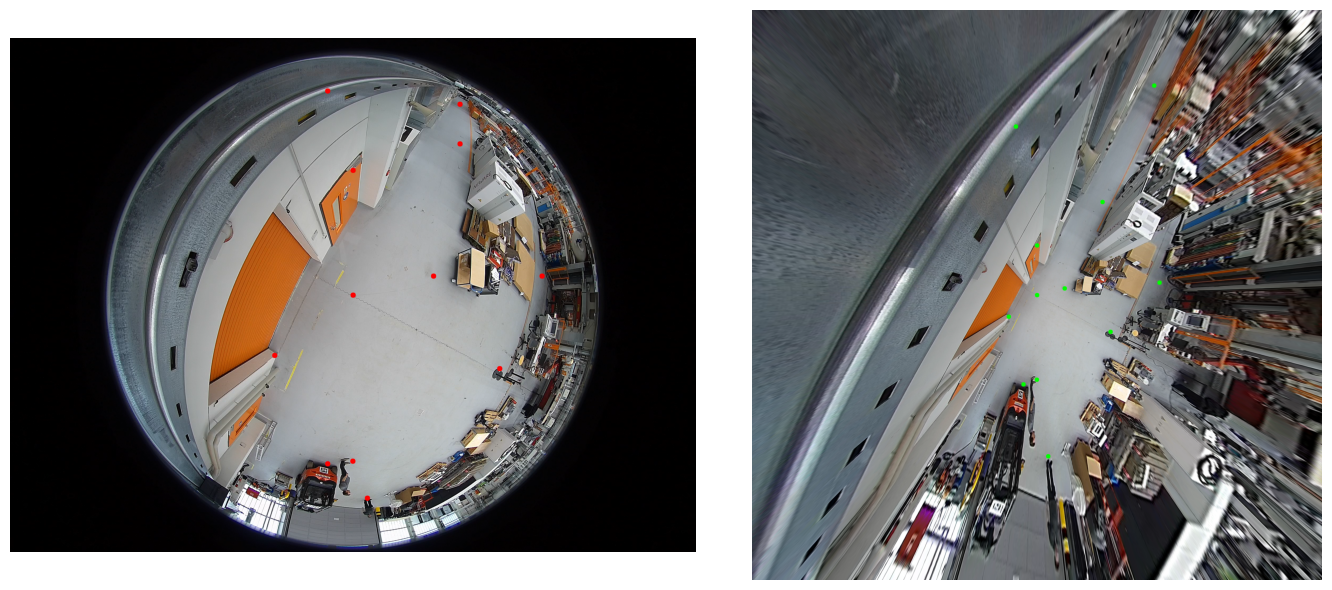

In [116]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708  
}

fisheye_img = cv2.imread("20251104_115055.png")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]


rect_w, rect_h = 2560, 2560
fov = 160.0
fov_RAD = np.deg2rad(fov)
focal = (rect_w / 2) / np.tan(fov_RAD / 2)

K_rect = np.array([[focal, 0.0, rect_w / 2],
                   [0.0, focal, rect_h / 2],
                   [0.0, 0.0, 1.0]])

f_fish = radius / theta_max
K_fish = np.array([[f_fish, 0.0, cx_f],
                   [0.0, f_fish, cy_f],
                   [0.0, 0.0, 1.0]])
D_fish = np.zeros((4, 1)) 


balance = 1.0
dim_rect = (rect_w, rect_h)
rectilinear = cv2.fisheye.undistortImage(fisheye_img, K_fish, D_fish, Knew=K_rect, new_size=dim_rect)


fisheye_points = np.array([
    [1296, 972],     
    [1600, 900],     
    [1000, 1200],    
    [1296, 500],     
    [1295, 1600],
    [1200, 1610],
    [1350, 1740],
    [1700, 250],
    [1200, 200],
    [1700, 400],
    [1850, 1250],
    [2010, 900]     
])

fisheye_points = fisheye_points.astype(np.float32)
fisheye_points = fisheye_points.reshape(-1,1,2)

rect_points = cv2.fisheye.undistortPoints(fisheye_points, K_fish, D_fish, P=K_rect)
print(rect_points.shape)
rect_points = rect_points.reshape(-1, 2)
rect_points = rect_points.astype(np.int32)
fisheye = fisheye_img.copy()
rect = rectilinear.copy()


for (pf, pr) in zip(fisheye_points.reshape(-1, 2), rect_points):
    cv2.circle(fisheye, (int(pf[0]), int(pf[1])), 10, (0, 0, 255), -1)
    cv2.circle(rect, (int(pr[0]), int(pr[1])), 10, (0, 255, 0), -1)
    print(f"Fisheye point ({pf[0]:.1f}, {pf[1]:.1f}) Rectified point ({pr[0]:.1f}, {pr[1]:.1f})")


fisheye_rgb = cv2.cvtColor(fisheye, cv2.COLOR_BGR2RGB)
rect_rgb = cv2.cvtColor(rect, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(fisheye_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rect_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()




In [ ]:
import cv2

# Read the image
img = cv2.imread("cam.png")


if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    # Resize to (width=2592, height=1944)
    resized_img = cv2.resize(img, (2592, 1944))

    # Save or display the result
    cv2.imwrite("cam_resize.png", resized_img)
    print("Image resized successfully!")
    print("Original shape:", img.shape)
    print("Resized shape:", resized_img.shape)

    # (Optional) Show the image
    cv2.imshow("Resized Image", resized_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
 

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708  
}

fisheye_img = cv2.imread("20251104_115055.png")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]


rect_w, rect_h = 2560, 2560
fov = 160.0
fov_RAD = np.deg2rad(fov)
focal = (rect_w / 2) / np.tan(fov_RAD / 2)

K_rect = np.array([[focal, 0.0, rect_w / 2],
                   [0.0, focal, rect_h / 2],
                   [0.0, 0.0, 1.0]])

f_fish = radius / theta_max
K_fish = np.array([[f_fish, 0.0, cx_f],
                   [0.0, f_fish, cy_f],
                   [0.0, 0.0, 1.0]])
D_fish = np.zeros((4, 1)) 


balance = 1.0
dim_rect = (rect_w, rect_h)
rectilinear = cv2.fisheye.undistortImage(fisheye_img, K_fish, D_fish, Knew=K_rect, new_size=dim_rect)


fisheye_points = np.array([
    [1296, 972],     
    [1600, 900],     
    [1000, 1200],    
    [1296, 500],     
    [1295, 1600],
    [1200, 1610],
    [1350, 1740],
    [1700, 250],
    [1200, 200],
    [1700, 400],
    [1850, 1250],
    [2010, 900]     
])

fisheye_points = fisheye_points.astype(np.float32)
fisheye_points = fisheye_points.reshape(-1,1,2)

rect_points = cv2.fisheye.undistortPoints(fisheye_points, K_fish, D_fish, P=K_rect)
print(rect_points.shape)
rect_points = rect_points.reshape(-1, 2)
rect_points = rect_points.astype(np.int32)
fisheye = fisheye_img.copy()
rect = rectilinear.copy()


for (pf, pr) in zip(fisheye_points.reshape(-1, 2), rect_points):
    cv2.circle(fisheye, (int(pf[0]), int(pf[1])), 10, (0, 0, 255), -1)
    cv2.circle(rect, (int(pr[0]), int(pr[1])), 10, (0, 255, 0), -1)
    print(f"Fisheye point ({pf[0]:.1f}, {pf[1]:.1f}) Rectified point ({pr[0]:.1f}, {pr[1]:.1f})")


fisheye_rgb = cv2.cvtColor(fisheye, cv2.COLOR_BGR2RGB)
rect_rgb = cv2.cvtColor(rect, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(fisheye_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rect_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()




In [1]:
import cv2

# --- Read image ---
img = cv2.imread("rect_rgb_fov_140.jpg")

if img is None:
    print("❌ Error: Image not found or could not be loaded.")
    exit()

target_width = 1280
target_height = 720


img_resized = cv2.resize(img, (target_width, target_height))
print(f"✅ Image resized to: {img_resized.shape[1]}x{img_resized.shape[0]}")

r = cv2.selectROI("Select Crop Area", img_resized, fromCenter=False, showCrosshair=True)


x, y, w, h = map(int, r)
print(f"Selected region: x={x}, y={y}, width={w}, height={h}")

# --- Crop the selected area ---
cropped = img_resized[y:y+h, x:x+w]

# --- Show and Save result ---
cv2.imshow("Cropped Image", cropped)
cv2.imwrite("captures/fisheye_cropped.jpg", cropped)
print("✅ Cropped image saved as captures/fisheye_cropped.jpg")

cv2.waitKey(0)
cv2.destroyAllWindows()



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Nahush\anaconda3\envs\test_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
 

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import